In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df_172 = pd.read_excel('../data/All_GS_172-2.xlsx')
df_j5= pd.read_excel('../data/All-J5 .xlsx')
df_j7a=pd.read_excel('../data/All-J7A.xlsx')

In [3]:
df_172= df_172.iloc[:,[0,1,2]]
df_j5= df_j5.iloc[:,[0,1,2]]
df_j7a= df_j7a.iloc[:,[0,1,2]]


In [4]:
# Create a list of your dataframes and their names for easy iteration
wells = [
    (df_172, "GS-172"),
    (df_j5, "J5"),
    (df_j7a, "J7A")
]

print(f"{'Well Name':<12} | {'Top (ft)':<10} | {'Bottom (ft)':<10} | {'Interval (ft)':<15} | {'Samples':<8}")
print("-" * 65)

for df, name in wells:
    # 1. Identify the Depth column (it's the first column)
    depth_col = df.columns[0]
    
    # 2. Extract Top and Bottom
    top_depth = df[depth_col].min()
    bottom_depth = df[depth_col].max()
    
    # 3. Calculate the physical Interval (Vertical thickness)
    interval = bottom_depth - top_depth
    
    # 4. Get the count of data points (Samples)
    num_samples = len(df)
    
    print(f"{name:<12} | {top_depth:<10.2f} | {bottom_depth:<10.2f} | {interval:<15.2f} | {num_samples:<8}")

Well Name    | Top (ft)   | Bottom (ft) | Interval (ft)   | Samples 
-----------------------------------------------------------------
GS-172       | 5000.00    | 5150.00    | 150.00          | 150     
J5           | 5000.00    | 5150.00    | 150.00          | 150     
J7A          | 5000.00    | 5150.00    | 150.00          | 150     


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# --- 2. DTW ALGORITHM WITH SAKOE-CHIBA CONSTRAINT ---
def dtw_sakoe_chiba(s1, s2, window_percent=0.15):
    """
    Computes the DTW distance between two standardized log sequences.
    window_percent: The width of the Sakoe-Chiba constraint band.
    """
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Calculate window size and ensure it covers the difference in log lengths
    window = int(window_percent * max(n, m))
    window = max(window, abs(n - m))

    for i in range(1, n + 1):
        # Calculate within the Sakoe-Chiba band
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            # Cost is the absolute difference between standardised values
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                          dtw_matrix[i, j-1],    # deletion
                                          dtw_matrix[i-1, j-1])  # match
    return dtw_matrix[n, m]

# --- 3. STANDARDIZATION (Z-Score) ---
scaler = StandardScaler()


In [6]:
# Standardize the NPHI for your 3 existing dataframes
nphi_172 = scaler.fit_transform(df_172[['Neutron Porosity']].values).flatten()
nphi_j7a = scaler.fit_transform(df_j7a[['Neutron Porosity']].values).flatten()
nphi_j5 = scaler.fit_transform(df_j5[['Neutron Porosity']].values).flatten()
# converting gr values such that MEAN =0 STD DEV =1

# Calculate NPHI Distances for all combinations
dist_nphi_172_j7a = dtw_sakoe_chiba(nphi_172, nphi_j7a, int(0.15 * max(len(nphi_172), len(nphi_j7a))))
dist_nphi_j7a_j5 = dtw_sakoe_chiba(nphi_j7a, nphi_j5, int(0.15 * max(len(nphi_j7a), len(nphi_j5))))
dist_nphi_j5_172 = dtw_sakoe_chiba(nphi_j5, nphi_172, int(0.15 * max(len(nphi_j5), len(nphi_172))))

print(f"NPHI Distance 172-J7a: {dist_nphi_172_j7a:.2f}")
print(f"NPHI Distance J7A-J5: {dist_nphi_j7a_j5:.2f}")
print(f"NPHI Distance J5-172: {dist_nphi_j5_172:.2f}")



from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standardize the GR for your 3 existing dataframes
gr_172= scaler.fit_transform(df_172[['GR (API)']].values).flatten()
gr_j7a = scaler.fit_transform(df_j7a[['GR (API)']].values).flatten()
gr_j5 = scaler.fit_transform(df_j5[['GR (API)']].values).flatten()

# Calculate GR Distances for all combinations
# NO159-2 to J6A
dist_gr_172_j7a = dtw_sakoe_chiba(gr_172, gr_j7a, int(0.15 * max(len(gr_172), len(gr_j7a))))

# J6A to J4
dist_gr_j7a_j5 = dtw_sakoe_chiba(gr_j7a, gr_j5, int(0.15 * max(len(gr_j7a), len(gr_j5))))

# J4 to NO159-2
dist_gr_j5_172 = dtw_sakoe_chiba(gr_j5, gr_172, int(0.15 * max(len(gr_j5), len(gr_172))))

print(f"GR Distance 179-J7A: {dist_gr_172_j7a:.2f}")
print(f"GR Distance J7A-J5: {dist_gr_j7a_j5:.2f}")
print(f"GR Distance J5-179: {dist_gr_j5_172:.2f}")

NPHI Distance 172-J7a: 82.75
NPHI Distance J7A-J5: 79.81
NPHI Distance J5-172: 82.23
GR Distance 179-J7A: 84.07
GR Distance J7A-J5: 77.45
GR Distance J5-179: 87.17


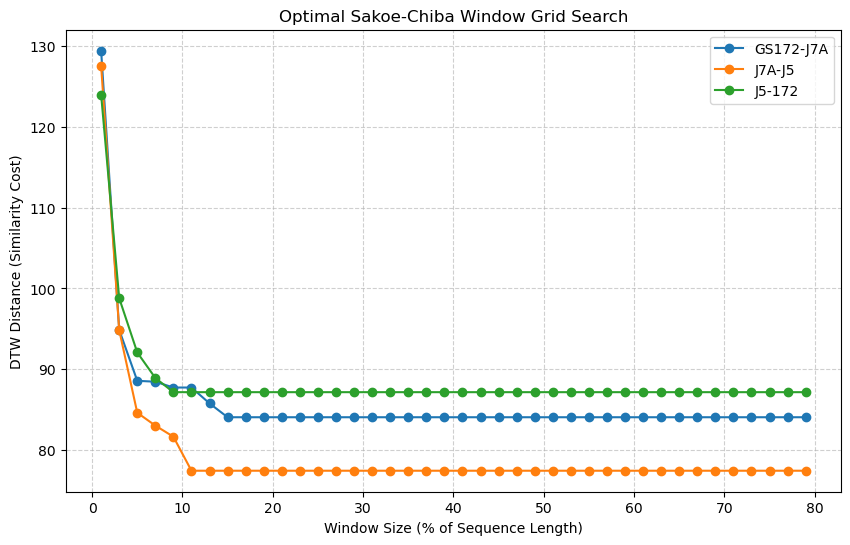

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Define DTW with Sakoe-Chiba
def dtw_sakoe_chiba(s1, s2, window):
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    # Window must be at least the difference in lengths
    window = max(window, abs(n - m))
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], dtw_matrix[i, j-1], dtw_matrix[i-1, j-1])
    return dtw_matrix[n, m]

# 2. Standardize GR Logs (Assuming your df_no159, df_j6a, df_j4 are ready)
scaler = StandardScaler()
gr_172 = scaler.fit_transform(df_172[['GR (API)']].values).flatten()
gr_j7a = scaler.fit_transform(df_j7a[['GR (API)']].values).flatten()
gr_j5 = scaler.fit_transform(df_j5[['GR (API)']].values).flatten()

# 3. Perform Grid Search (1% to 60%)
window_percents = np.arange(1, 80, 2)
combos = [(gr_172, gr_j7a, "GS172-J7A"), (gr_j7a, gr_j5, "J7A-J5"), (gr_j5, gr_172, "J5-172")]
all_results = {}

for s1, s2, label in combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    all_results[label] = distances

# 4. Plot the Elbow Curves
plt.figure(figsize=(10, 6))
for label, distances in all_results.items():
    plt.plot(window_percents, distances, marker='o', label=label)

plt.title('Optimal Sakoe-Chiba Window Grid Search')
plt.xlabel('Window Size (% of Sequence Length)')
plt.ylabel('DTW Distance (Similarity Cost)')
plt.savefig('GR_Sakoe.png', dpi=300, bbox_inches='tight')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [8]:
# Create a small function to find the first percentage that hits the 'floor'
def get_best_window(percent_list, distance_list):
    # Find the minimum distance achieved
    min_dist = min(distance_list)
    # Find the index of the first time that minimum was reached
    best_index = distance_list.index(min_dist)
    # Return the corresponding percentage
    return percent_list[best_index]

# Use the variables from your previous grid search loop
best_172_j7a = get_best_window(window_percents.tolist(), all_results["GS172-J7A"])
best_j7a_j5 = get_best_window(window_percents.tolist(), all_results["J7A-J5"])
best_j5_172 = get_best_window(window_percents.tolist(), all_results["J5-172"])

print(f"Optimal Window for 172-J7A: {best_172_j7a}%")
print(f"Optimal Window for J7A-J5: {best_j7a_j5}%")
print(f"Optimal Window for J5-172: {best_j5_172}%")

Optimal Window for 172-J7A: 15%
Optimal Window for J7A-J5: 11%
Optimal Window for J5-172: 9%


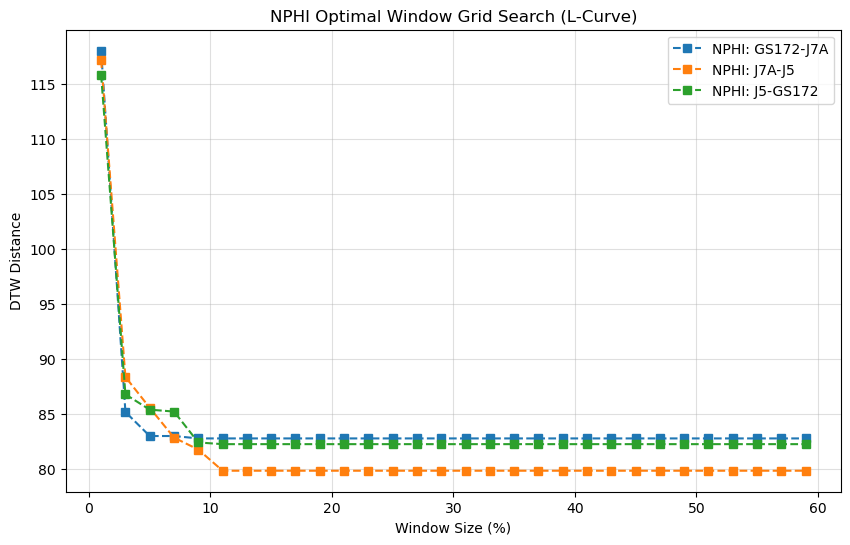

--- Optimized NPHI Windows ---
GS172-J7A: 5%
J7A-J5:    11%
J5-172:  9%


In [9]:
# 1. Define the range for NPHI Grid Search
window_percents = np.arange(1, 61, 2)
nphi_combos = [
    (nphi_172, nphi_j7a, "GS172-J7A"), 
    (nphi_j7a, nphi_j5, "J7A-J5"), 
    (nphi_j5, nphi_172, "J5-GS172")
]

nphi_grid_results = {}

# 2. Execute Grid Search for NPHI
for s1, s2, label in nphi_combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    nphi_grid_results[label] = distances

# 3. Plot NPHI L-Curves
plt.figure(figsize=(10, 6))
for label, distances in nphi_grid_results.items():
    plt.plot(window_percents, distances, marker='s', linestyle='--', label=f"NPHI: {label}")

plt.title('NPHI Optimal Window Grid Search (L-Curve)')
plt.xlabel('Window Size (%)')
plt.ylabel('DTW Distance')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

# 4. Function to identify the 'Elbow' (First point of stability)
def find_nphi_best_window(p_list, d_list):
    # Find the absolute minimum distance
    min_d = min(d_list)
    # Find the first index where the distance is within 0.5% of the minimum
    for i, d in enumerate(d_list):
        if (d - min_d) / min_d < 0.005:
            return p_list[i]
    return p_list[-1]

# 5. Output the Best Windows for NPHI
best_nphi_172_j7a = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["GS172-J7A"])
best_nphi_j7a_j5 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J7A-J5"])
best_nphi_j5_172 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J5-GS172"])

print(f"--- Optimized NPHI Windows ---")
print(f"GS172-J7A: {best_nphi_172_j7a}%")
print(f"J7A-J5:    {best_nphi_j7a_j5}%")
print(f"J5-172:  {best_nphi_j5_172}%")

## wARPING path

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Publication-ready styling (Standardized for all plots)
# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 30,
    "axes.titlesize": 34,
    "legend.fontsize": 30,
    "figure.figsize": (18, 18),
    "axes.linewidth": 2.0
})
def find_elbow(p_list, d_list):
    min_d = min(d_list)
    for i, d in enumerate(d_list):
        if (d - min_d) / (min_d if min_d != 0 else 1) < 0.005:
            return p_list[i], d_list[i]
    return p_list[-1], d_list[-1]

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Publication-ready styling (Standardized for all plots)
# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 30,       # Matches Warping Path Axis Labels
    "axes.titlesize": 34,       # Matches Warping Path Title
    "legend.fontsize": 30,      # Matches Warping Path Legend
    "figure.figsize": (18, 18), # Matches Warping Path Figure Size
    "axes.linewidth": 2.0       # Matches Warping Path Spine thickness
})

def find_elbow(p_list, d_list):
    min_d = min(d_list)
    for i, d in enumerate(d_list):
        if (d - min_d) / (min_d if min_d != 0 else 1) < 0.005:
            return p_list[i], d_list[i]
    return p_list[-1], d_list[-1]

In [13]:
x_gr = np.arange(1, 80, 2)
y_gr = all_results["J7A-J5"]
best_p, best_d = find_elbow(x_gr.tolist(), y_gr)









In [14]:
import matplotlib.pyplot as plt
import numpy as np
import os
'''
def plot_research_l_curve_save(window_percents, distances, label, log_name):
    # Find the "Elbow" / Stability Point
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    # Ensure standard publication fonts are applied locally if not in rcParams
    plt.rcParams.update({"font.family": "serif"})
    
    fig, ax = plt.subplots(figsize=(18, 18))

    # Main curve
    ax.plot(window_percents, distances, marker='o', ms=12, 
            lw=5, color='#1f77b4', label=f'DTW Cost ({log_name})')
    
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimum point
    ax.scatter(best_window, min_dist, color='red', edgecolor='black', 
               s=600, marker='*', zorder=10)
    
    # Annotation
    ax.annotate(f'Optimum Window: {best_window:.1f}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, min_dist + (max(distances) - min_dist) * 0.25),
                fontsize=30, fontweight='bold',
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=3),
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))

    ax.set_title(f'Optimization: {label} ({log_name})', fontsize=34, fontweight='bold', pad=30)
    ax.set_xlabel('Sakoe-Chiba Window Size (% of Sequence Length)', fontsize=30, fontweight='bold', labelpad=15)
    ax.set_ylabel('DTW Distance (Similarity Cost)', fontsize=30, fontweight='bold', labelpad=15)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=30, width=3, length=12)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    # Border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(3.0)
    
    ax.legend(fontsize=30, loc='upper right', frameon=True, shadow=True)

    # --- SAVE LOGIC ---
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    
    # Saving as JPG with 300 DPI
    save_path = f"L_curve/{label}_{log_name.replace(' ', '_')}_LCurve.jpg"
    plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')
    
    print(f"Success! Research-grade L-curve saved to: {save_path}")
    plt.show()
'''
# --- EXECUTION ---
label = "J7A-J5"
y_values = all_results[label]
num_points = len(y_values)
x_values = np.linspace(1, 79, num_points).tolist()

#plot_research_l_curve_save(x_values, y_values, label, "Gamma Ray")

In [15]:
import matplotlib.pyplot as plt

'''def plot_research_l_curve(window_percents, distances, label, log_name):
    # Find the "Elbow" / Stability Point
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    fig, ax = plt.subplots()  # uses your rcParams size (18x18)

# Main curve
    color = '#2ca02c' if log_name == "Neutron Porosity" else '#1f77b4'

    ax.plot(window_percents, distances, marker='s', ms=12, 
        lw=5, color=color, label=f'DTW Cost ({log_name})')
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimum point
    ax.scatter(best_window, min_dist, color='red', edgecolor='black', 
               s=400, marker='*', zorder=10)
    
    # Annotation (same style)
    ax.annotate(f'Optimum Window: {best_window}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, min_dist + (max(distances) - min_dist) * 0.25),
                fontsize=30, fontweight='bold',
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=2),
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))

    ax.set_title(f'Optimization: {label} ({log_name})', pad=30)
    ax.set_xlabel('Sakoe-Chiba Window Size (% of Sequence Length)', labelpad=15)
    ax.set_ylabel('DTW Distance (Similarity Cost)', labelpad=15)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=8)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')
    
    ax.legend(fontsize=30, loc='upper right', frameon=True, shadow=True)
    import os

# Save figure
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    
    save_path = f"L_curve/{label}_{log_name.replace(' ', '_')}_L_Curve.png"
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Saved: {save_path}")
# --- PLOT GR CURVES ---
# --- PLOT GR CURVES (FIXED) ---'''

label = "J7A-J5"  # GS172-2 vs J5

y_values = nphi_grid_results["J7A-J5"]
num_points = len(y_values)

x_values = np.arange(1, 61, 2).tolist()
#plot_research_l_curve(x_values, y_values, label, "Neutron Porosity")

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Zone definitions from your provided data
zones_j7a = {
    'Asl Marl': (5000, 5042, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5042, 5092, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5092, 5130, '#d9ead3')   # Light Green
}

zones_j5= {
    'Asl Marl': (5000, 5048, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5048, 5098, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5098, 5130, '#d9ead3')   # Light Green
}

# We'll assume J6A follows a similar stratigraphic sequence 
# based on your window search results.

In [17]:
def plot_correlation(df1, df2, label1, label2, window_p):
    fig, axes = plt.subplots(1, 2, figsize=(10, 12), sharey=False)
    
    # Calculate warping path using your dtw_sakoe_chiba logic
    # (Extract the path indices i, j from your DTW matrix)
    # path = get_dtw_path(s1, s2, window_p) 

    for ax, df, zones, name in zip(axes, [df1, df2], [zones_j7a, zones_j5], [label1, label2]):
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # Plot GR Log
        ax.plot(gr, depth, color='black', lw=0.7)
        ax.set_title(name)
        ax.invert_yaxis()
        
        # Color the Zones
        for zone, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, color=color, alpha=0.5, label=zone)
            # Add text label for lithology
            ax.text(ax.get_xlim()[1], (top+bottom)/2, zone, verticalalignment='center')

    # Draw Correlation Lines (Connect points using the DTW path)
    # This visually shows how the "Thick Beds" match despite depth shifts
    plt.tight_layout()
    plt.show()

# Example call using your optimized 37% window for NO159-J6A
# plot_correlation(df_no159, df_j6a, "NO159-2", "J6A", 0.37)

In [18]:
def dtw_with_path(s1, s2, window_p):
    n, m = len(s1), len(s2)
    window = max(int(window_p * max(n, m)), abs(n - m))
    
    # Initialize cost matrix
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Fill matrix
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # Backtrack to find the path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        # Find the minimum neighbor to step back to
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    
    return path[::-1] # Return path from beginning to end

## Final plotting 

Final bolded plot saved to: L_curve/J7A-J5_Gamma_Ray_Bold_Final.jpg


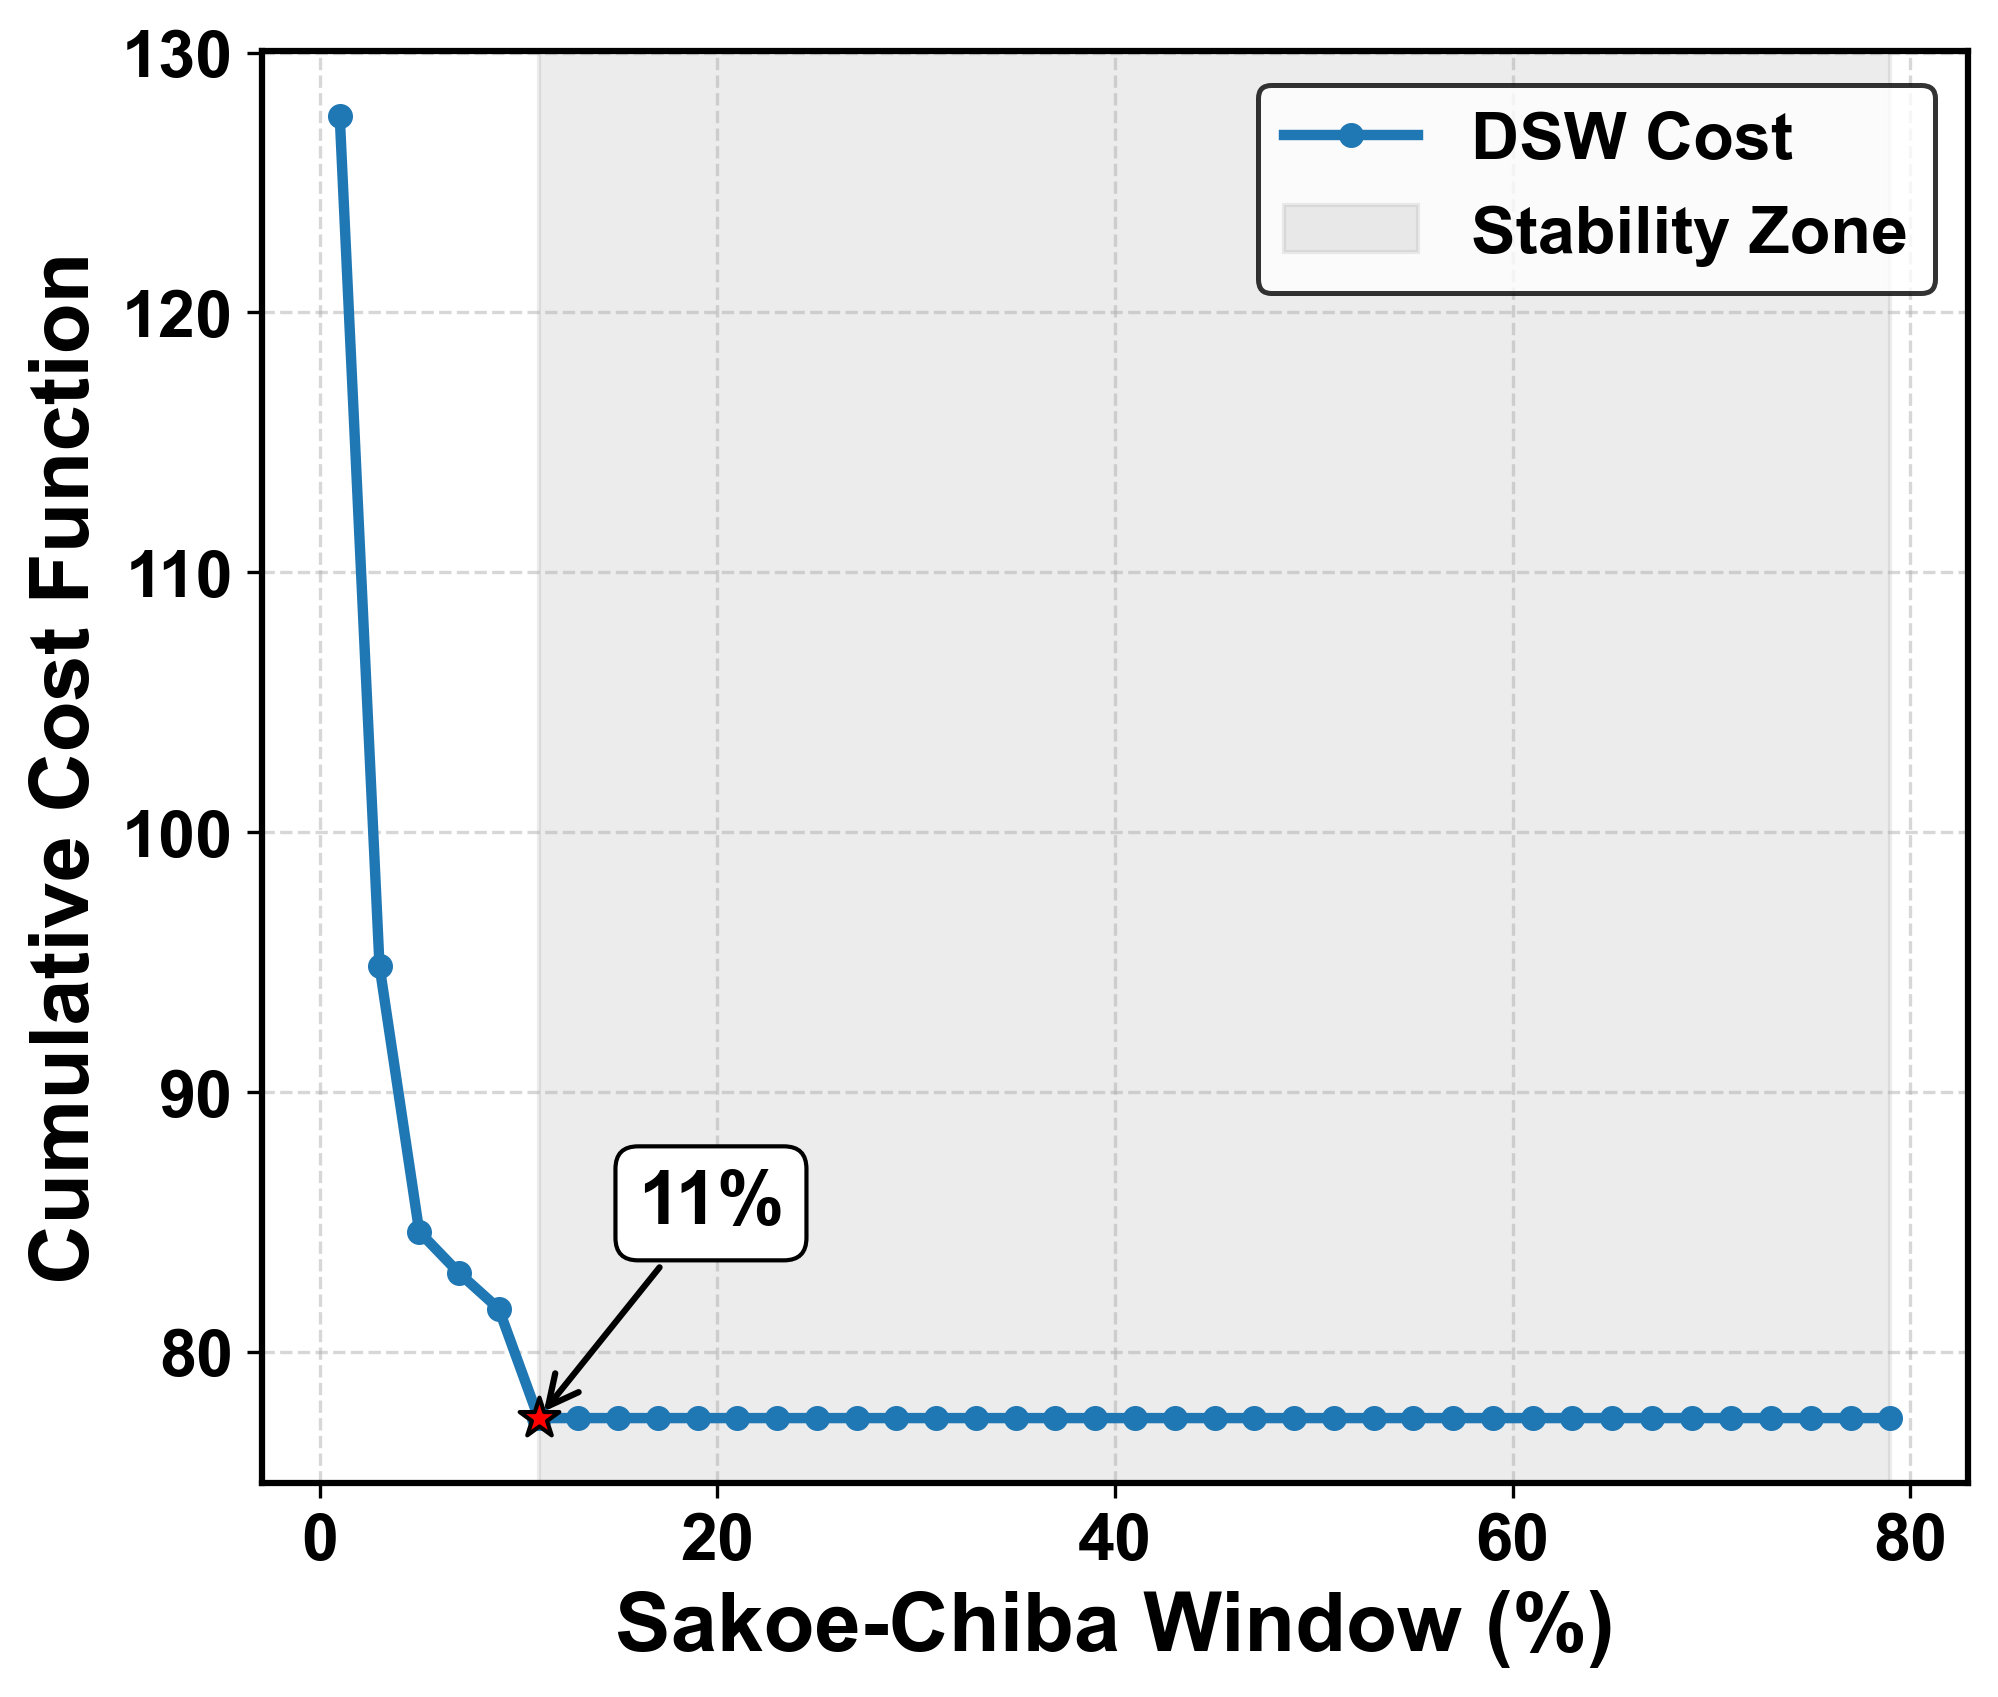

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. GLOBAL STYLE
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_research_l_curve_save_bold_final(window_percents, distances, label, log_name):
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    # Proportional y-offset for the annotation
    y_range = max(distances) - min_dist
    y_text_pos = min_dist + (y_range * 0.15) 

    fig, ax = plt.subplots(figsize=(7, 6))

    # Main curve
    ax.plot(window_percents, distances, color='#1f77b4', lw=2.5, 
            marker='o', ms=5, label='DSW Cost')
    
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimal point (Red Star)
    ax.scatter(best_window, min_dist, color='red', edgecolor='black', 
               s=100, marker='*', zorder=10)
    
    # 2. BOLD ANNOTATION (49%)
    ax.annotate(f'{int(best_window)}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, y_text_pos),
                fontsize=18,
                fontweight='bold',  # ✅ Makes 49% bold
                arrowprops=dict(arrowstyle='->', lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

    # Borders
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    ax.set_xlabel("Sakoe-Chiba Window (%)")
    ax.set_ylabel("Cumulative Cost Function")

    # 3. BOLD LEGEND
    leg = ax.legend(loc='upper right', frameon=True)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.2)
    for text in leg.get_texts():
        text.set_fontweight('bold')  # ✅ Makes Legend text bold

    ax.grid(True, linestyle='--', alpha=0.5)

    # Bold axis ticks
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    plt.tight_layout()

    # SAVE LOGIC
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    
    save_path = f"L_curve/{label}_{log_name.replace(' ', '_')}_Bold_Final.jpg"
    plt.savefig(save_path, dpi=400, format='jpg', bbox_inches='tight', pad_inches=0.02)
    
    print(f"Final bolded plot saved to: {save_path}")
    plt.show()

# --- EXECUTION ---
label = "J7A-J5"
y_values = all_results[label]
num_points = len(y_values)
x_values = np.linspace(1, 79, num_points).tolist()

plot_research_l_curve_save_bold_final(x_values, y_values, label, "Gamma Ray")

Full matrix plot saved to: L_curve/J5_J7A_Full_Matrix_GR.jpg


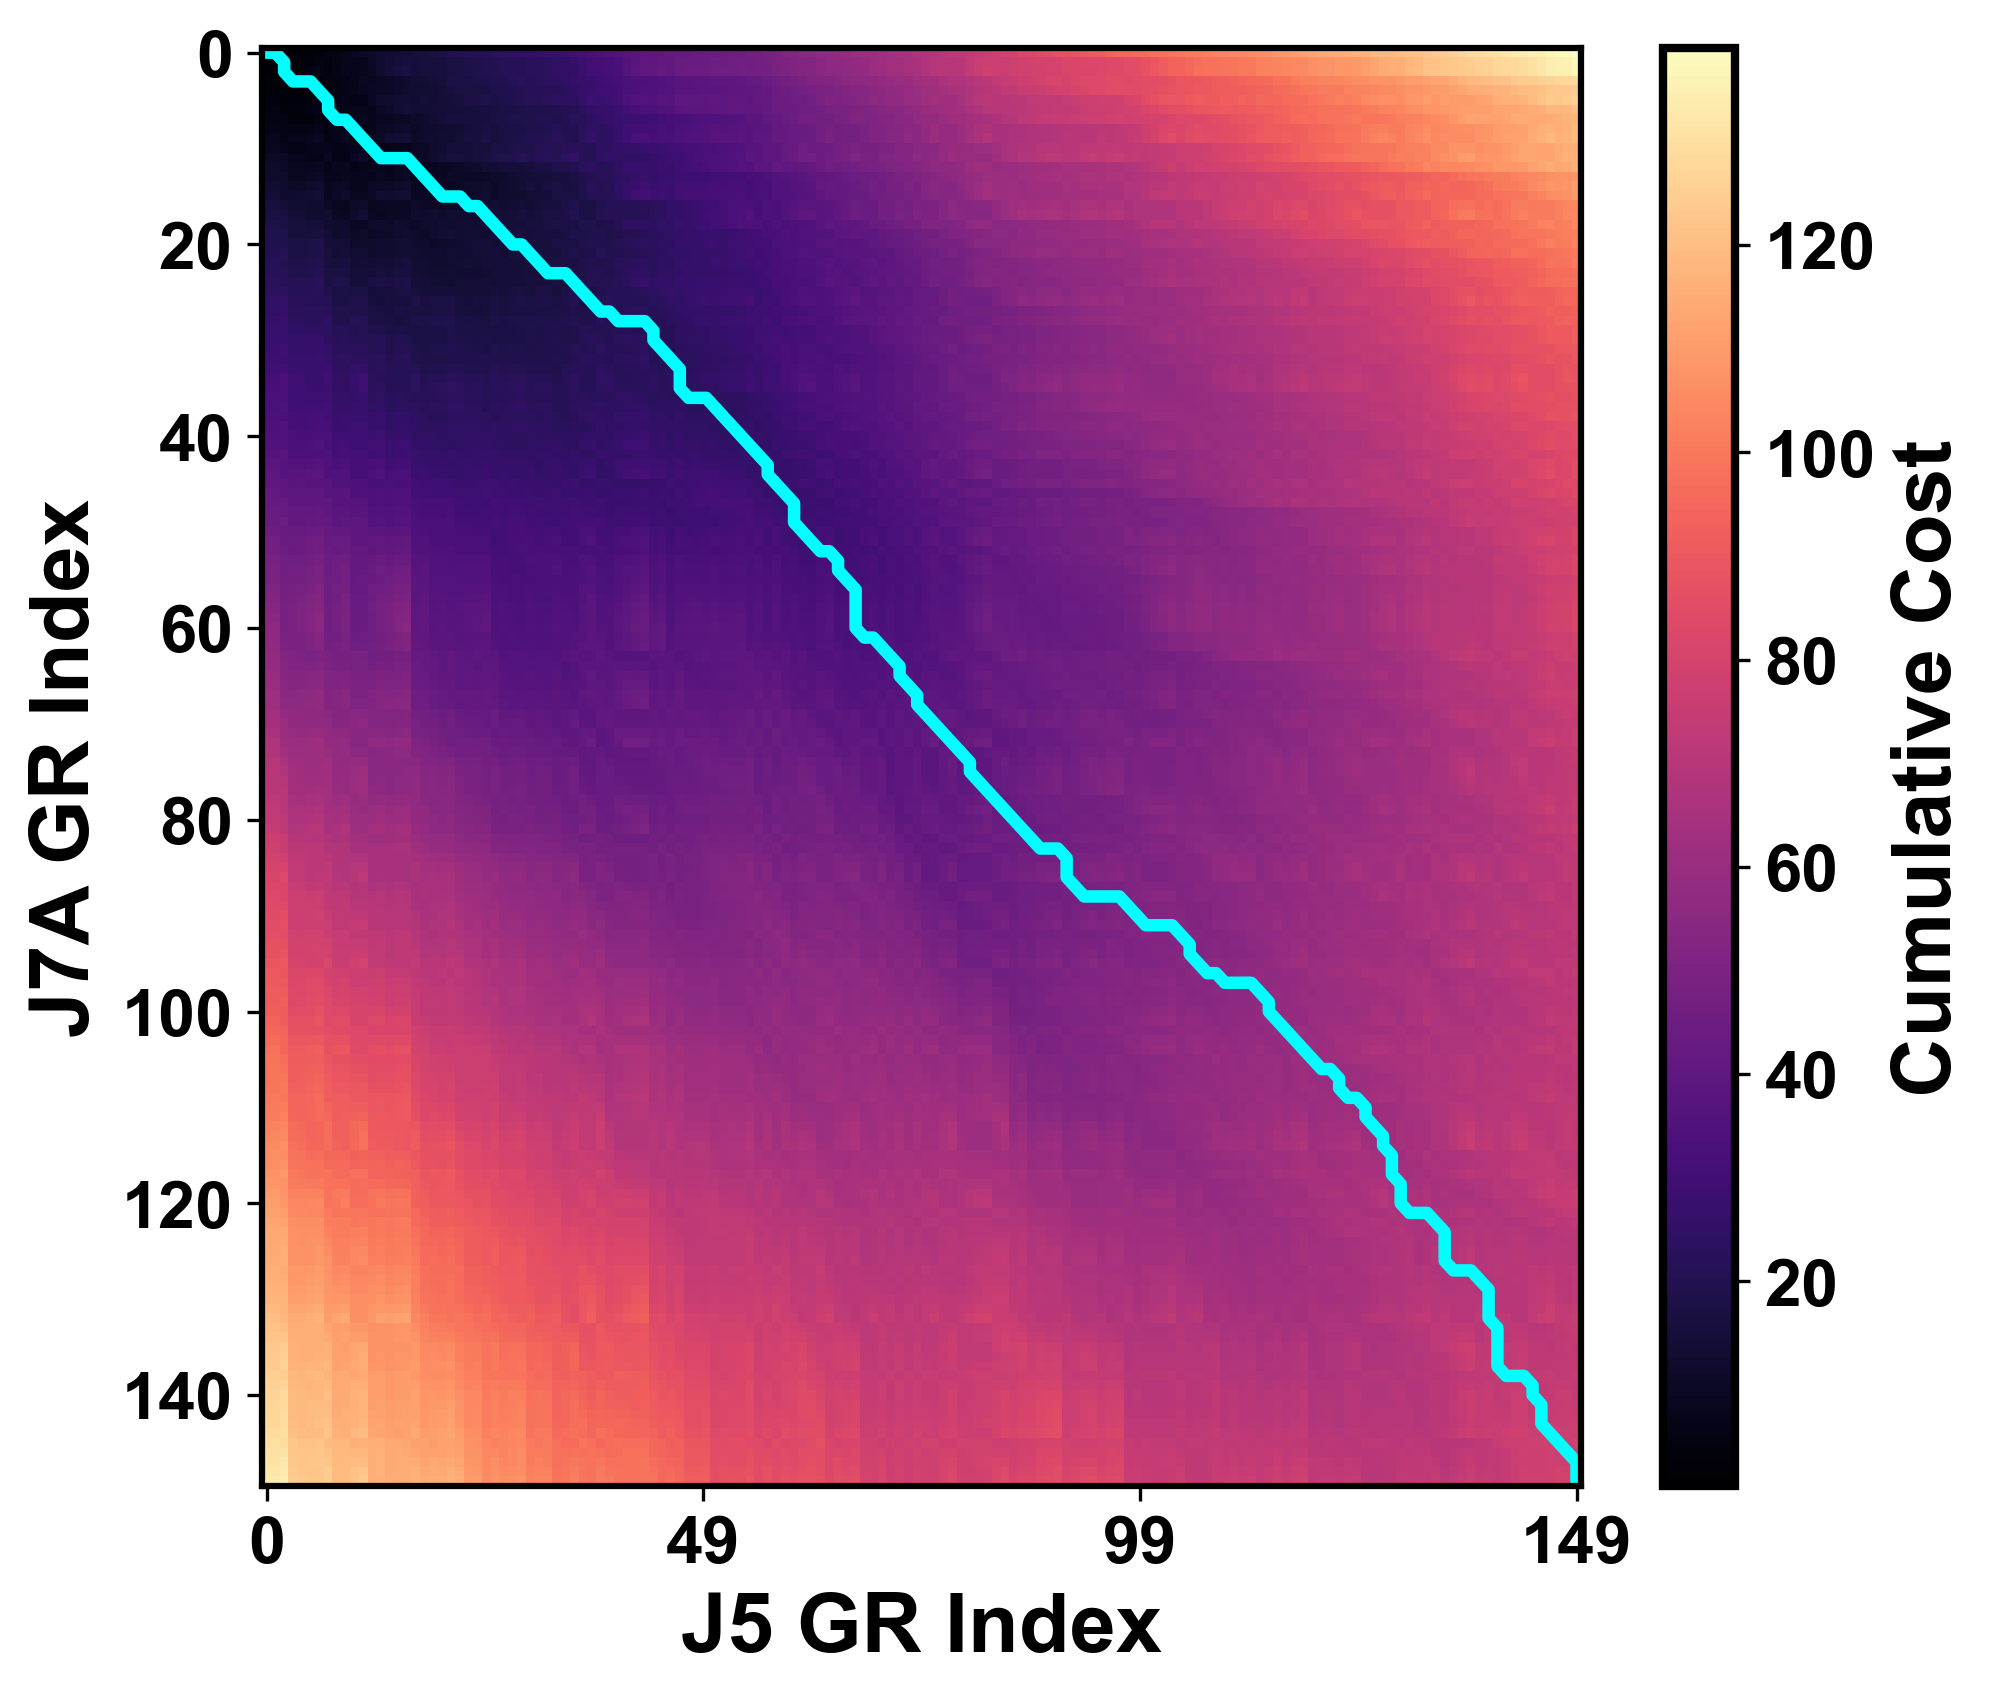

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# 1. GLOBAL STYLE
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_gr_full_matrix(df1, df2, label1, label2):
    # 1. Standardize GR logs
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    
    n, m = len(s1), len(s2)
    
    # 2. FULL DTW matrix (No Windowing)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):  # Full range i.e., 1 to m+1
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],    # Insertion
                dtw_matrix[i, j-1],    # Deletion
                dtw_matrix[i-1, j-1]   # Match
            )

    # 3. Backtracking for Optimal Path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. VISUALIZATION
    fig, ax = plt.subplots(figsize=(7, 6))

    # Using the full matrix (excluding the padding row/column)
    matrix = dtw_matrix[1:, 1:]

    img = ax.imshow(matrix.T, origin='upper', cmap='magma', aspect='auto')

    # Plot optimal path
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)

    # Labels
    ax.set_xlabel(f"{label1} GR Index")
    ax.set_ylabel(f"{label2} GR Index")

    # Tick density (4 ticks to match your NO159 style)
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])
    
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    # Colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost", fontweight='bold')
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    # Spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    ax.grid(False)
    plt.tight_layout()

    # Save
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_Full_Matrix_GR.jpg"
    plt.savefig(save_path, bbox_inches='tight')

    print(f"Full matrix plot saved to: {save_path}")
    plt.show()

# --- EXECUTE ---
plot_gr_full_matrix(df_j5, df_j7a, "J5", "J7A")

Matched Correlation Plot saved to: L_curve/J5_J7A_GR_Correlation_Matched.jpg


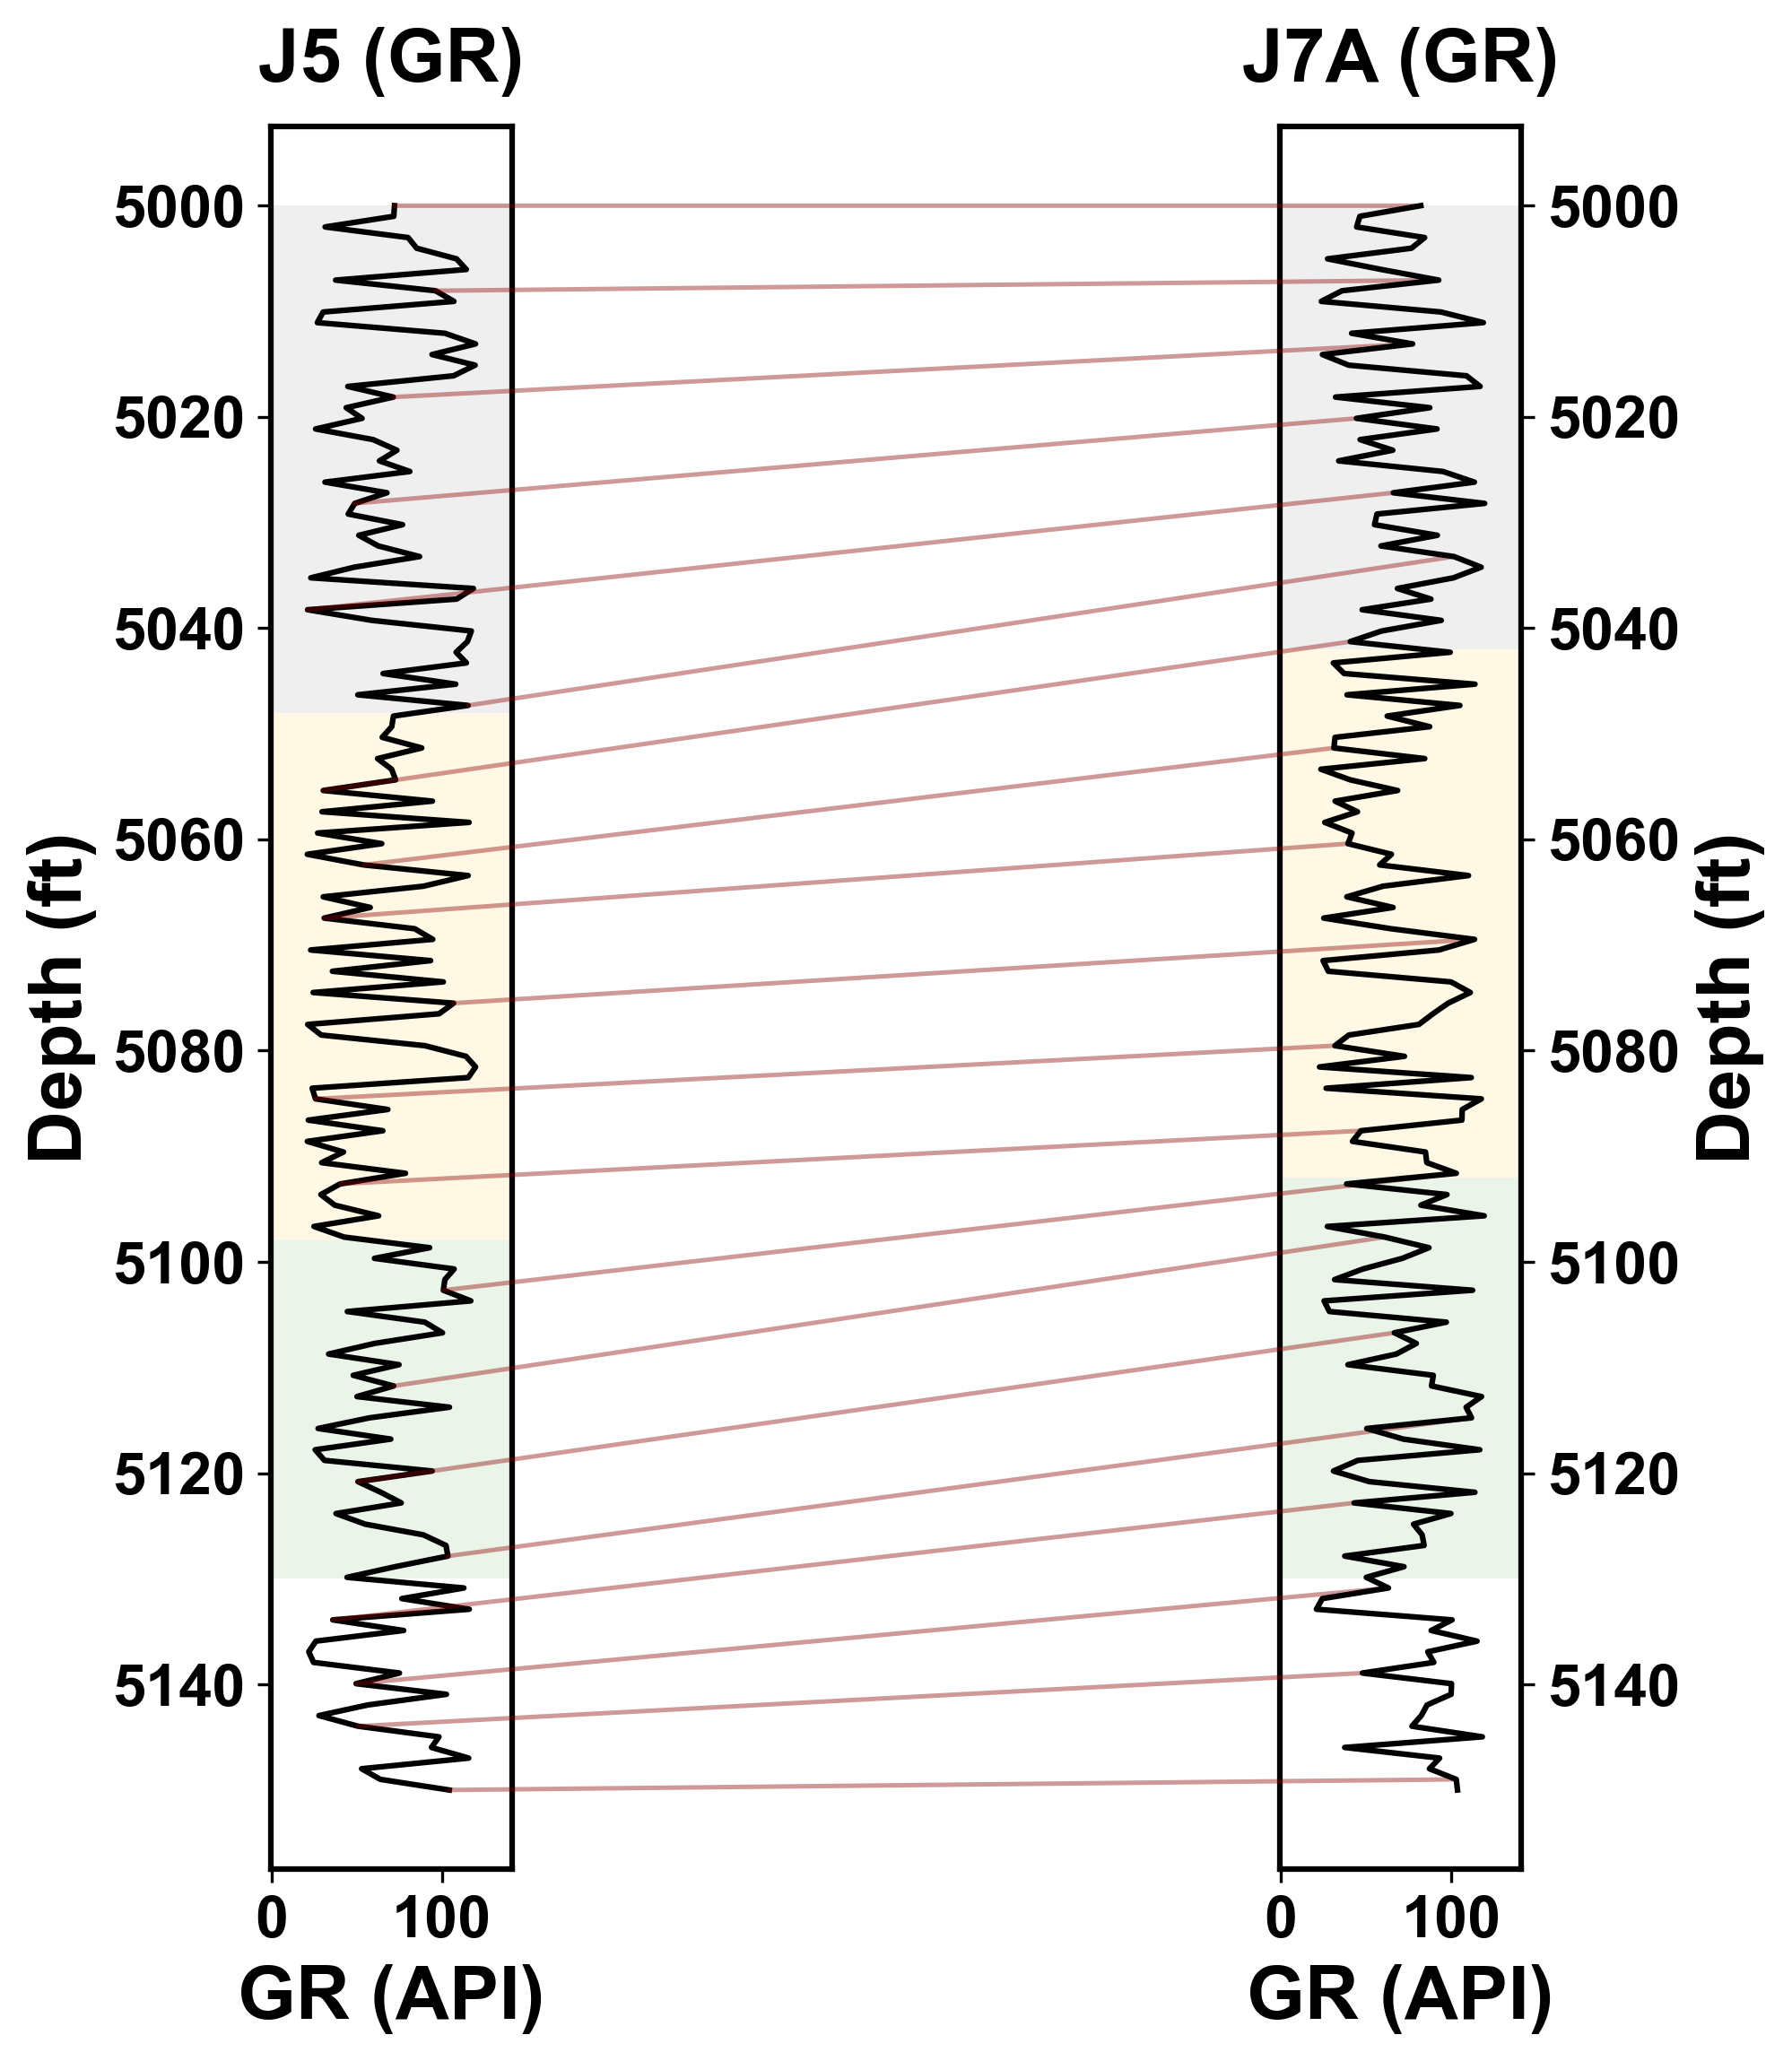

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import ConnectionPatch
import os

# 1. MATCHING GLOBAL STYLE (Arial + Clean Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

import matplotlib.pyplot as plt
import numpy as np
import os

# 1. GLOBAL STYLE (Arial + Clean Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import ConnectionPatch
import os

# 1. MATCHING GLOBAL STYLE (Arial + Clean Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_gr_correlation_matched(df1, df2, zones1, zones2, label1, label2, window_p):
    # 1. Standardize GR logs
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    
    # 2. Get DTW path
    path = dtw_with_path(s1, s2, window_p)
    
    # 3. MATCHING FIGURE SIZE (7x8)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8))

    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # LOG LINE (Black)
        ax.plot(gr, depth, color='black', lw=1.5, zorder=5)
        
        ax.invert_yaxis()
        # ✅ FIXED: Added standardized bold titles tracking track parameter type
        ax.set_title(f"{name} (GR)", fontweight='bold', pad=12)
        
        ax.set_xlabel("GR (API)")
        ax.set_ylabel("Depth (ft)")

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()

        # BOLD TICKS
        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontweight('bold')

        # STRATIGRAPHIC ZONES (Using facecolor to prevent matplotlib warnings)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # MATCHING WELL BOX WIDTH (Widen x-limits)
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Border/Spines
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')
            
        ax.grid(False)

    # 4. CORRELATION LINES (Dark Red, matches 1st code)
    # ✅ FIXED: Decreased density step from 120 to 10 for the short snippet range
    line_density_step = 10  
    for k in range(0, len(path), line_density_step):
        i1, i2 = path[k]
        y1, x1 = df1.iloc[i1, 0], df1.iloc[i1, 1]
        y2, x2 = df2.iloc[i2, 0], df2.iloc[i2, 1]

        con = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color="darkred", lw=1.2, alpha=0.4, zorder=4
        )
        axes[1].add_artist(con)

    # Clean up layout
    plt.tight_layout()
    
    # Save Logic
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_GR_Correlation_Matched.jpg"
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.05)

    print(f"Matched Correlation Plot saved to: {save_path}")
    plt.show()

# --- EXECUTE ---
# Passing dataframes along with the corrected dummy ranges and window parameter
plot_gr_correlation_matched(df_j5, df_j7a, zones_j5, zones_j7a, "J5", "J7A", 0.11)

## for nphi

NPHI L-Curve saved to: L_curve/J7A-J5_Neutron_Porosity_NPHI_Matched.jpg


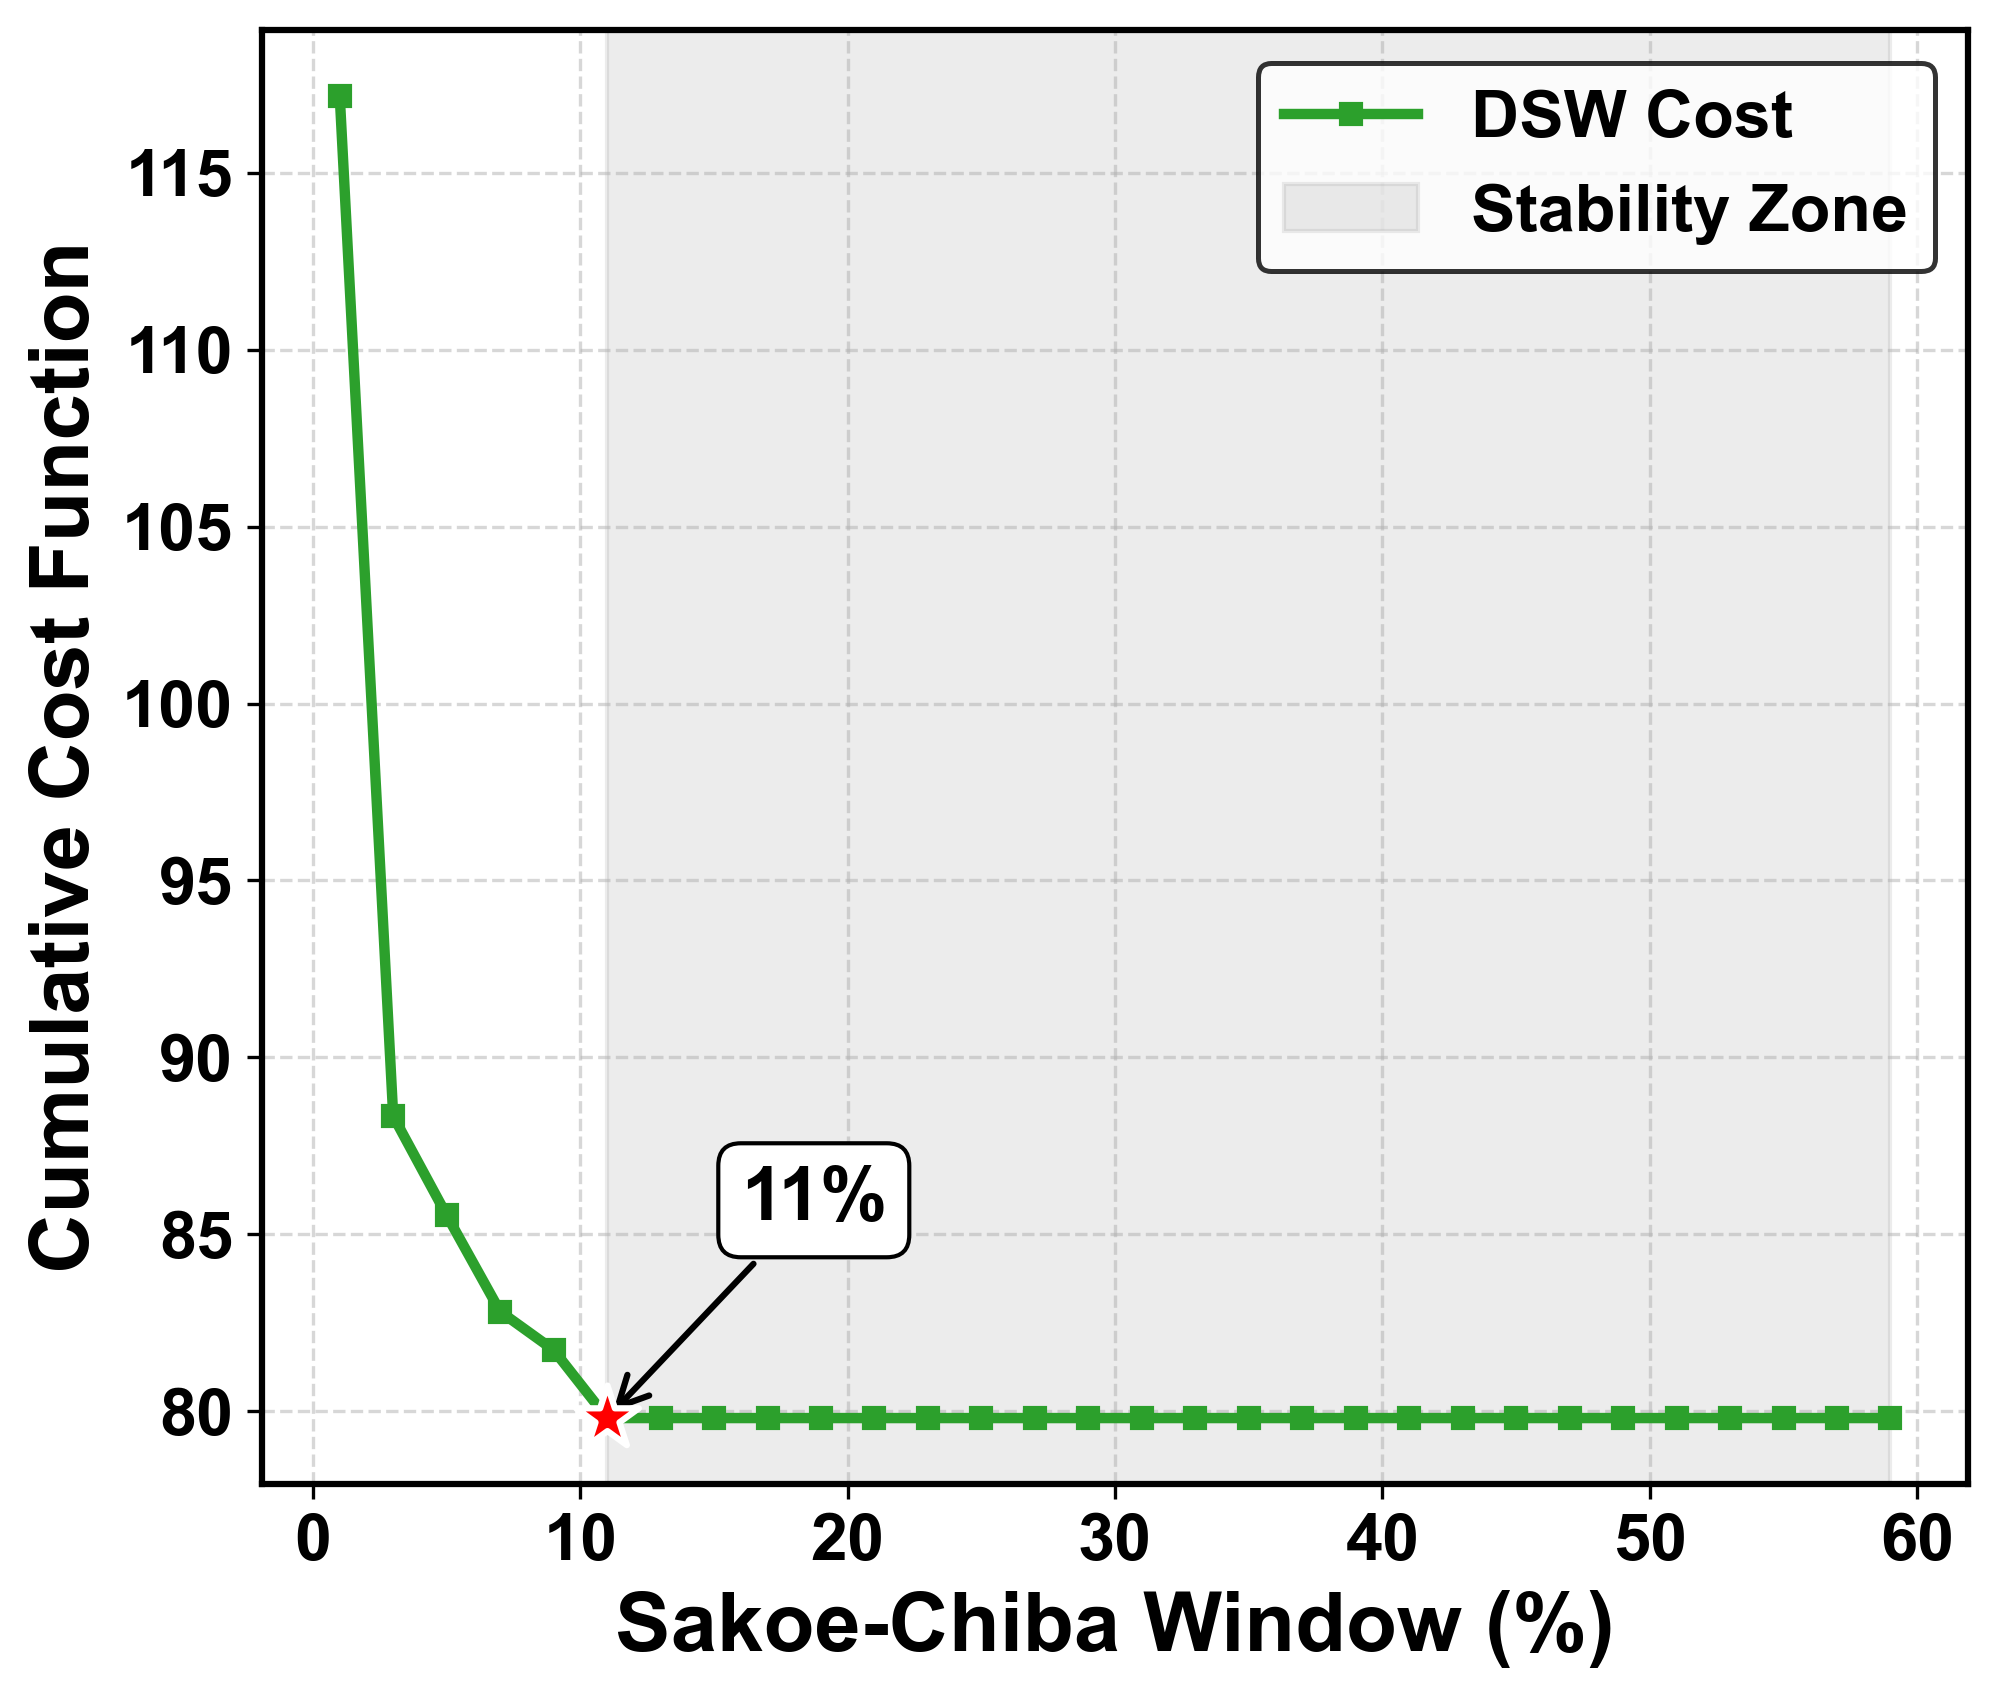

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. GLOBAL STYLE (Arial + Clean Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_research_l_curve_nphi_matched(window_percents, distances, label, log_name):
    # Find the "Elbow" / Stability Point
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    # 2. PROPORTIONAL OFFSET (Fixes the long arrow issue)
    y_range = max(distances) - min_dist
    y_text_pos = min_dist + (y_range * 0.15) 

    # 3. MATCHING FIGURE SIZE (7x6)
    fig, ax = plt.subplots(figsize=(7, 6))

    # Main curve (Green color #2ca02c and square markers 's')
    ax.plot(window_percents, distances, color='#2ca02c', lw=2.5, 
            marker='s', ms=5, label='DSW Cost')
    
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimal point (Red Star)
    ax.scatter(best_window, min_dist, color='red', edgecolor='white', 
               s=250, marker='*', zorder=20, linewidth=1.5)
    
    # 4. BOLD ANNOTATION (Matching % style)
    ax.annotate(f'{int(best_window)}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, y_text_pos),
                fontsize=18,
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

    # Borders
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    # Labels
    ax.set_xlabel("Sakoe-Chiba Window (%)")
    ax.set_ylabel("Cumulative Cost Function")

    # 5. MATCHING LEGEND (Bolded text)
    leg = ax.legend(loc='upper right', frameon=True)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.2)
    for text in leg.get_texts():
        text.set_fontweight('bold')

    ax.grid(True, linestyle='--', alpha=0.5)

    # Bold axis ticks
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    plt.tight_layout()

    # SAVE LOGIC
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    
    save_path = f"L_curve/{label}_{log_name.replace(' ', '_')}_NPHI_Matched.jpg"
    plt.savefig(save_path, dpi=400, format='jpg', bbox_inches='tight', pad_inches=0.02)
    
    print(f"NPHI L-Curve saved to: {save_path}")
    plt.show()

# --- EXECUTION ---
label = "J7A-J5"
y_values = nphi_grid_results["J7A-J5"]
x_values = np.arange(1, 61, 2).tolist()

plot_research_l_curve_nphi_matched(x_values, y_values, label, "Neutron Porosity")

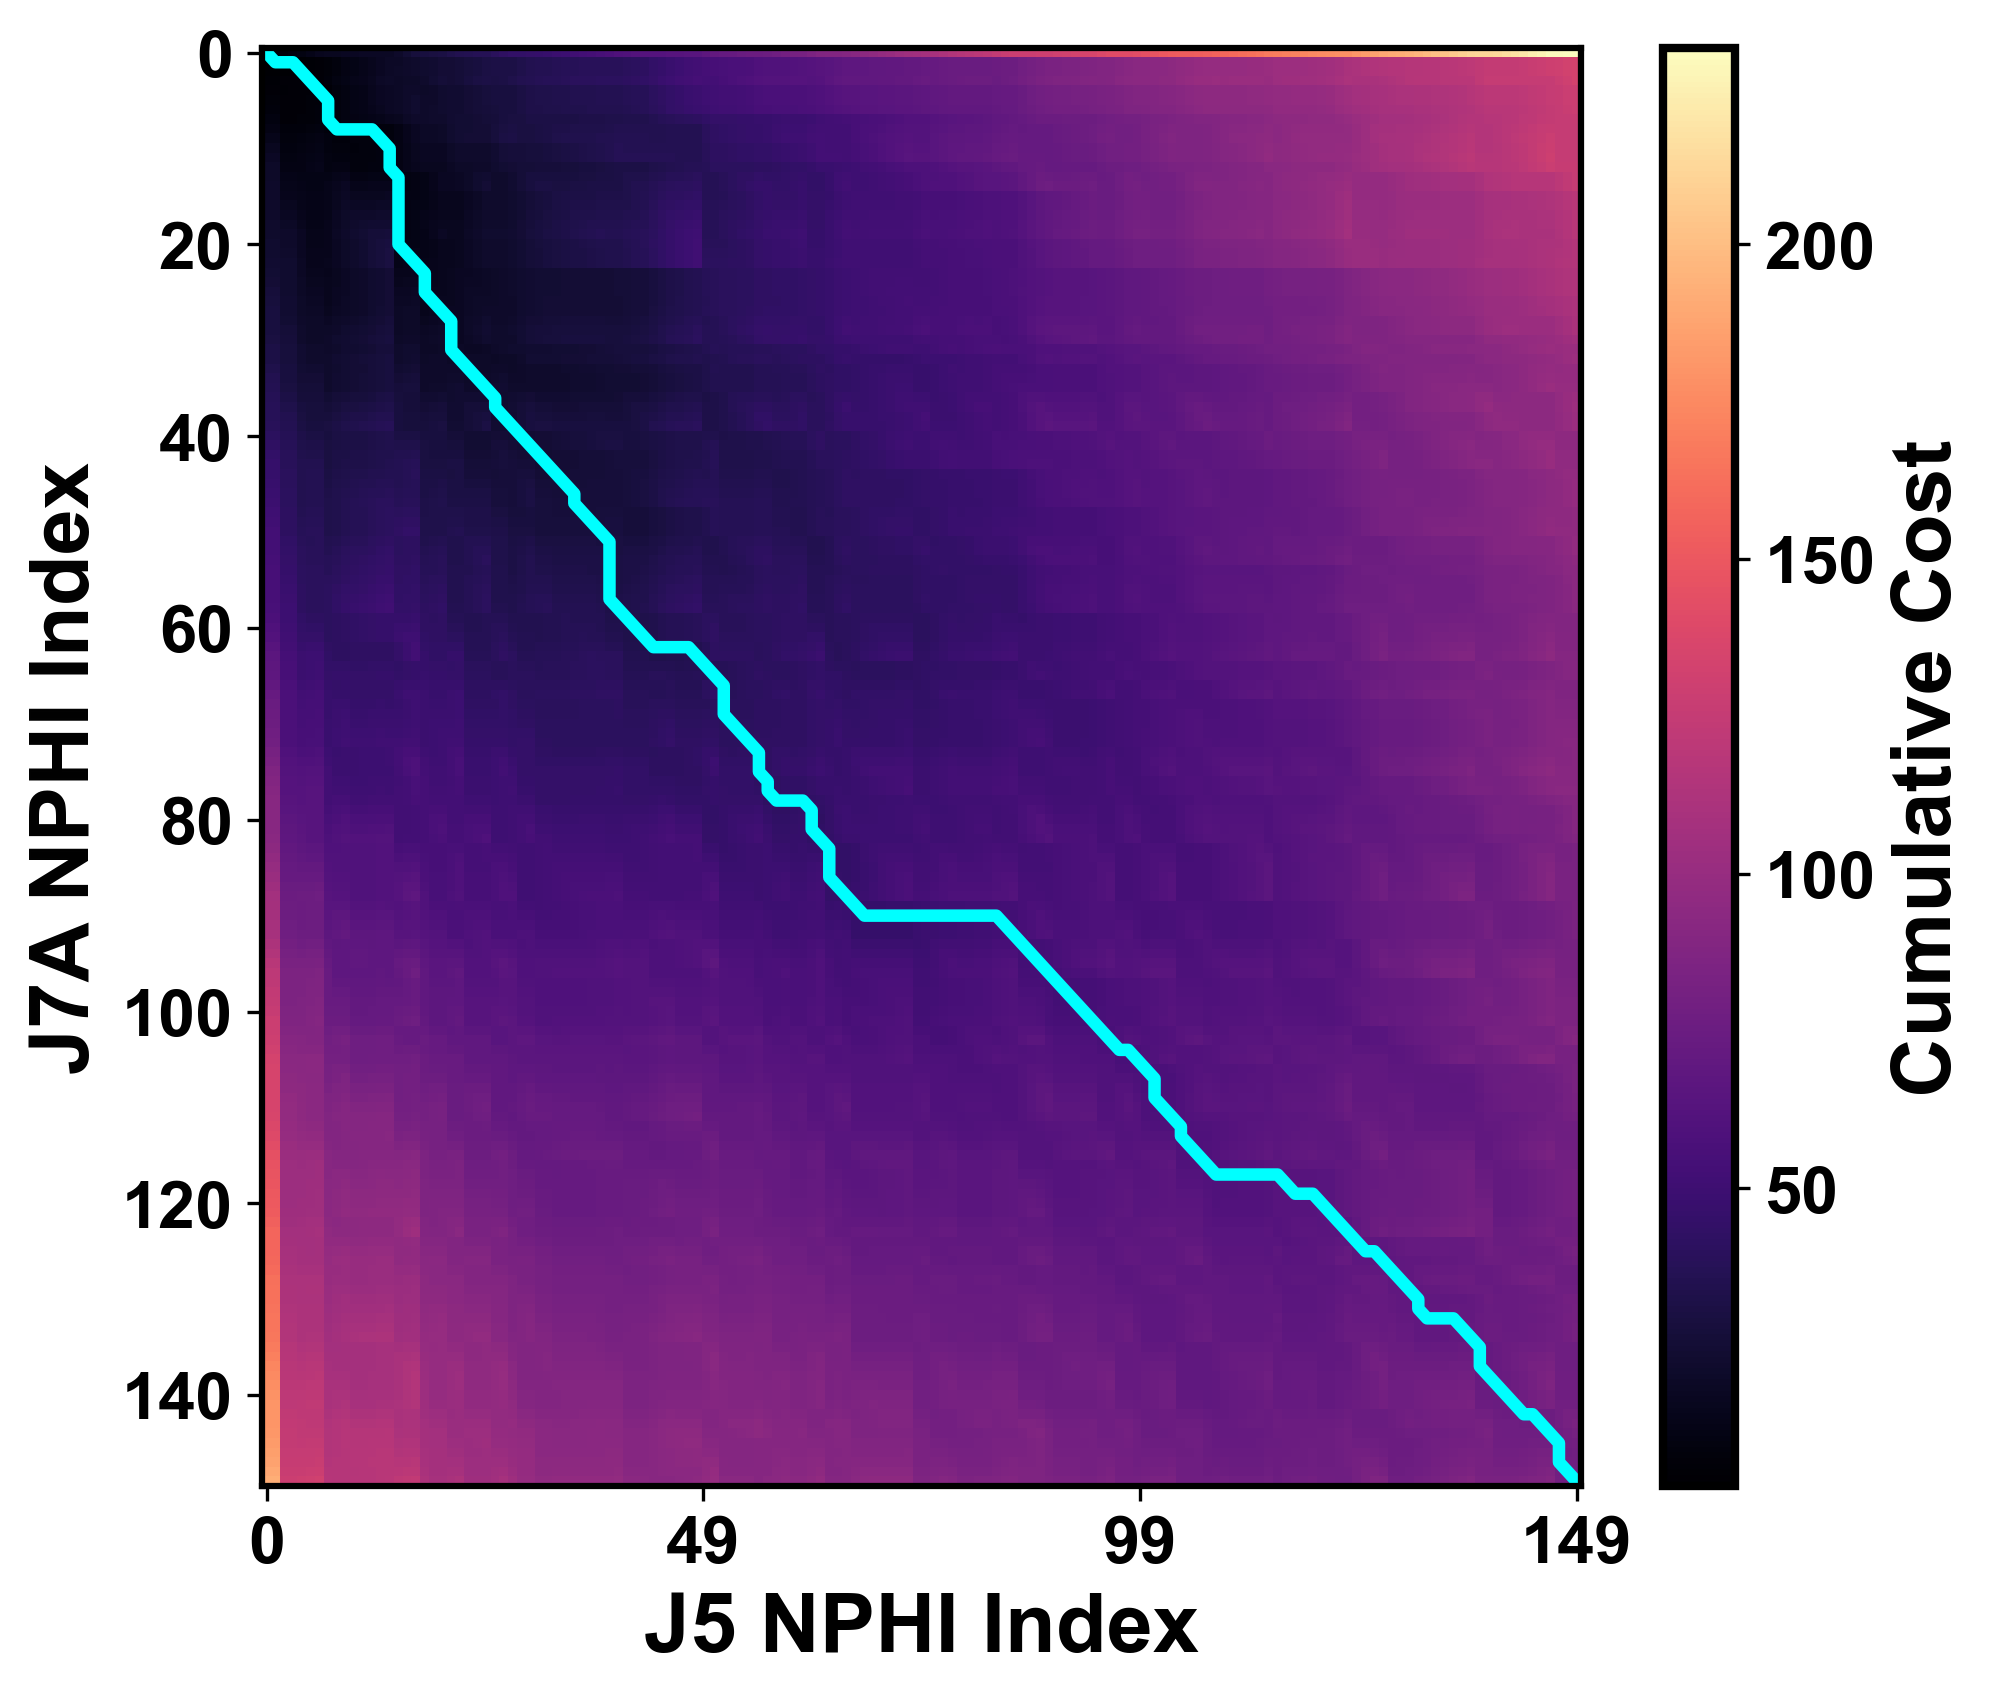

Full matrix warping plot saved to: L_curve/J5_J7A_NPHI_FullWarping.jpg


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.signal import medfilt
import os

# 1. STYLE CONFIGURATION (Arial + Publication Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300
})

def plot_nphi_full_warping_j5_j7(df1, df2, label1, label2):
    # Standardize NPHI (Column Index 2) with a median filter for stability
    scaler = StandardScaler()
    n1_smooth = medfilt(df1.iloc[:, 2].values, kernel_size=3)
    n2_smooth = medfilt(df2.iloc[:, 2].values, kernel_size=3)
    
    s1 = scaler.fit_transform(n1_smooth.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(n2_smooth.reshape(-1,1)).flatten()
    
    n, m = len(s1), len(s2)
    
    # 2. FULL MATRIX COMPUTATION (No Sakoe-Chiba Window)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # 3. BACKTRACK FOR OPTIMAL PATH
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        step = np.argmin([dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]])
        if step == 0: i, j = i-1, j-1
        elif step == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. VISUALIZATION (7x6 Aspect Ratio)
    fig, ax = plt.subplots(figsize=(7, 6))

    # Plot the full matrix (transpose for correct well orientation)
    matrix_to_plot = dtw_matrix[1:, 1:]
    img = ax.imshow(matrix_to_plot.T, origin='upper', cmap='magma', aspect='auto')

    # Overlay Optimal Path
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)

    # Labels (Matching NO159 "Index" style)
    ax.set_xlabel(f"{label1} NPHI Index")
    ax.set_ylabel(f"{label2} NPHI Index")

    # X-Tick Management (4 ticks for clarity)
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])
    
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    # Colorbar matching reference
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost", fontweight='bold')
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    # Spines and cleanup
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    plt.tight_layout()
    
    # Save Logic
    save_dir = 'L_curve'
    if not os.path.exists(save_dir): os.makedirs(save_dir)
    save_path = f"{save_dir}/{label1}_{label2}_NPHI_FullWarping.jpg"
    plt.savefig(save_path, bbox_inches='tight', dpi=400)
    
    plt.show()
    print(f"Full matrix warping plot saved to: {save_path}")

# --- EXECUTE ---
plot_nphi_full_warping_j5_j7(df_j5, df_j7a, "J5", "J7A")

Matched NPHI Correlation Plot saved to: L_curve/J5_J7A_NPHI_Correlation_Matched.jpg


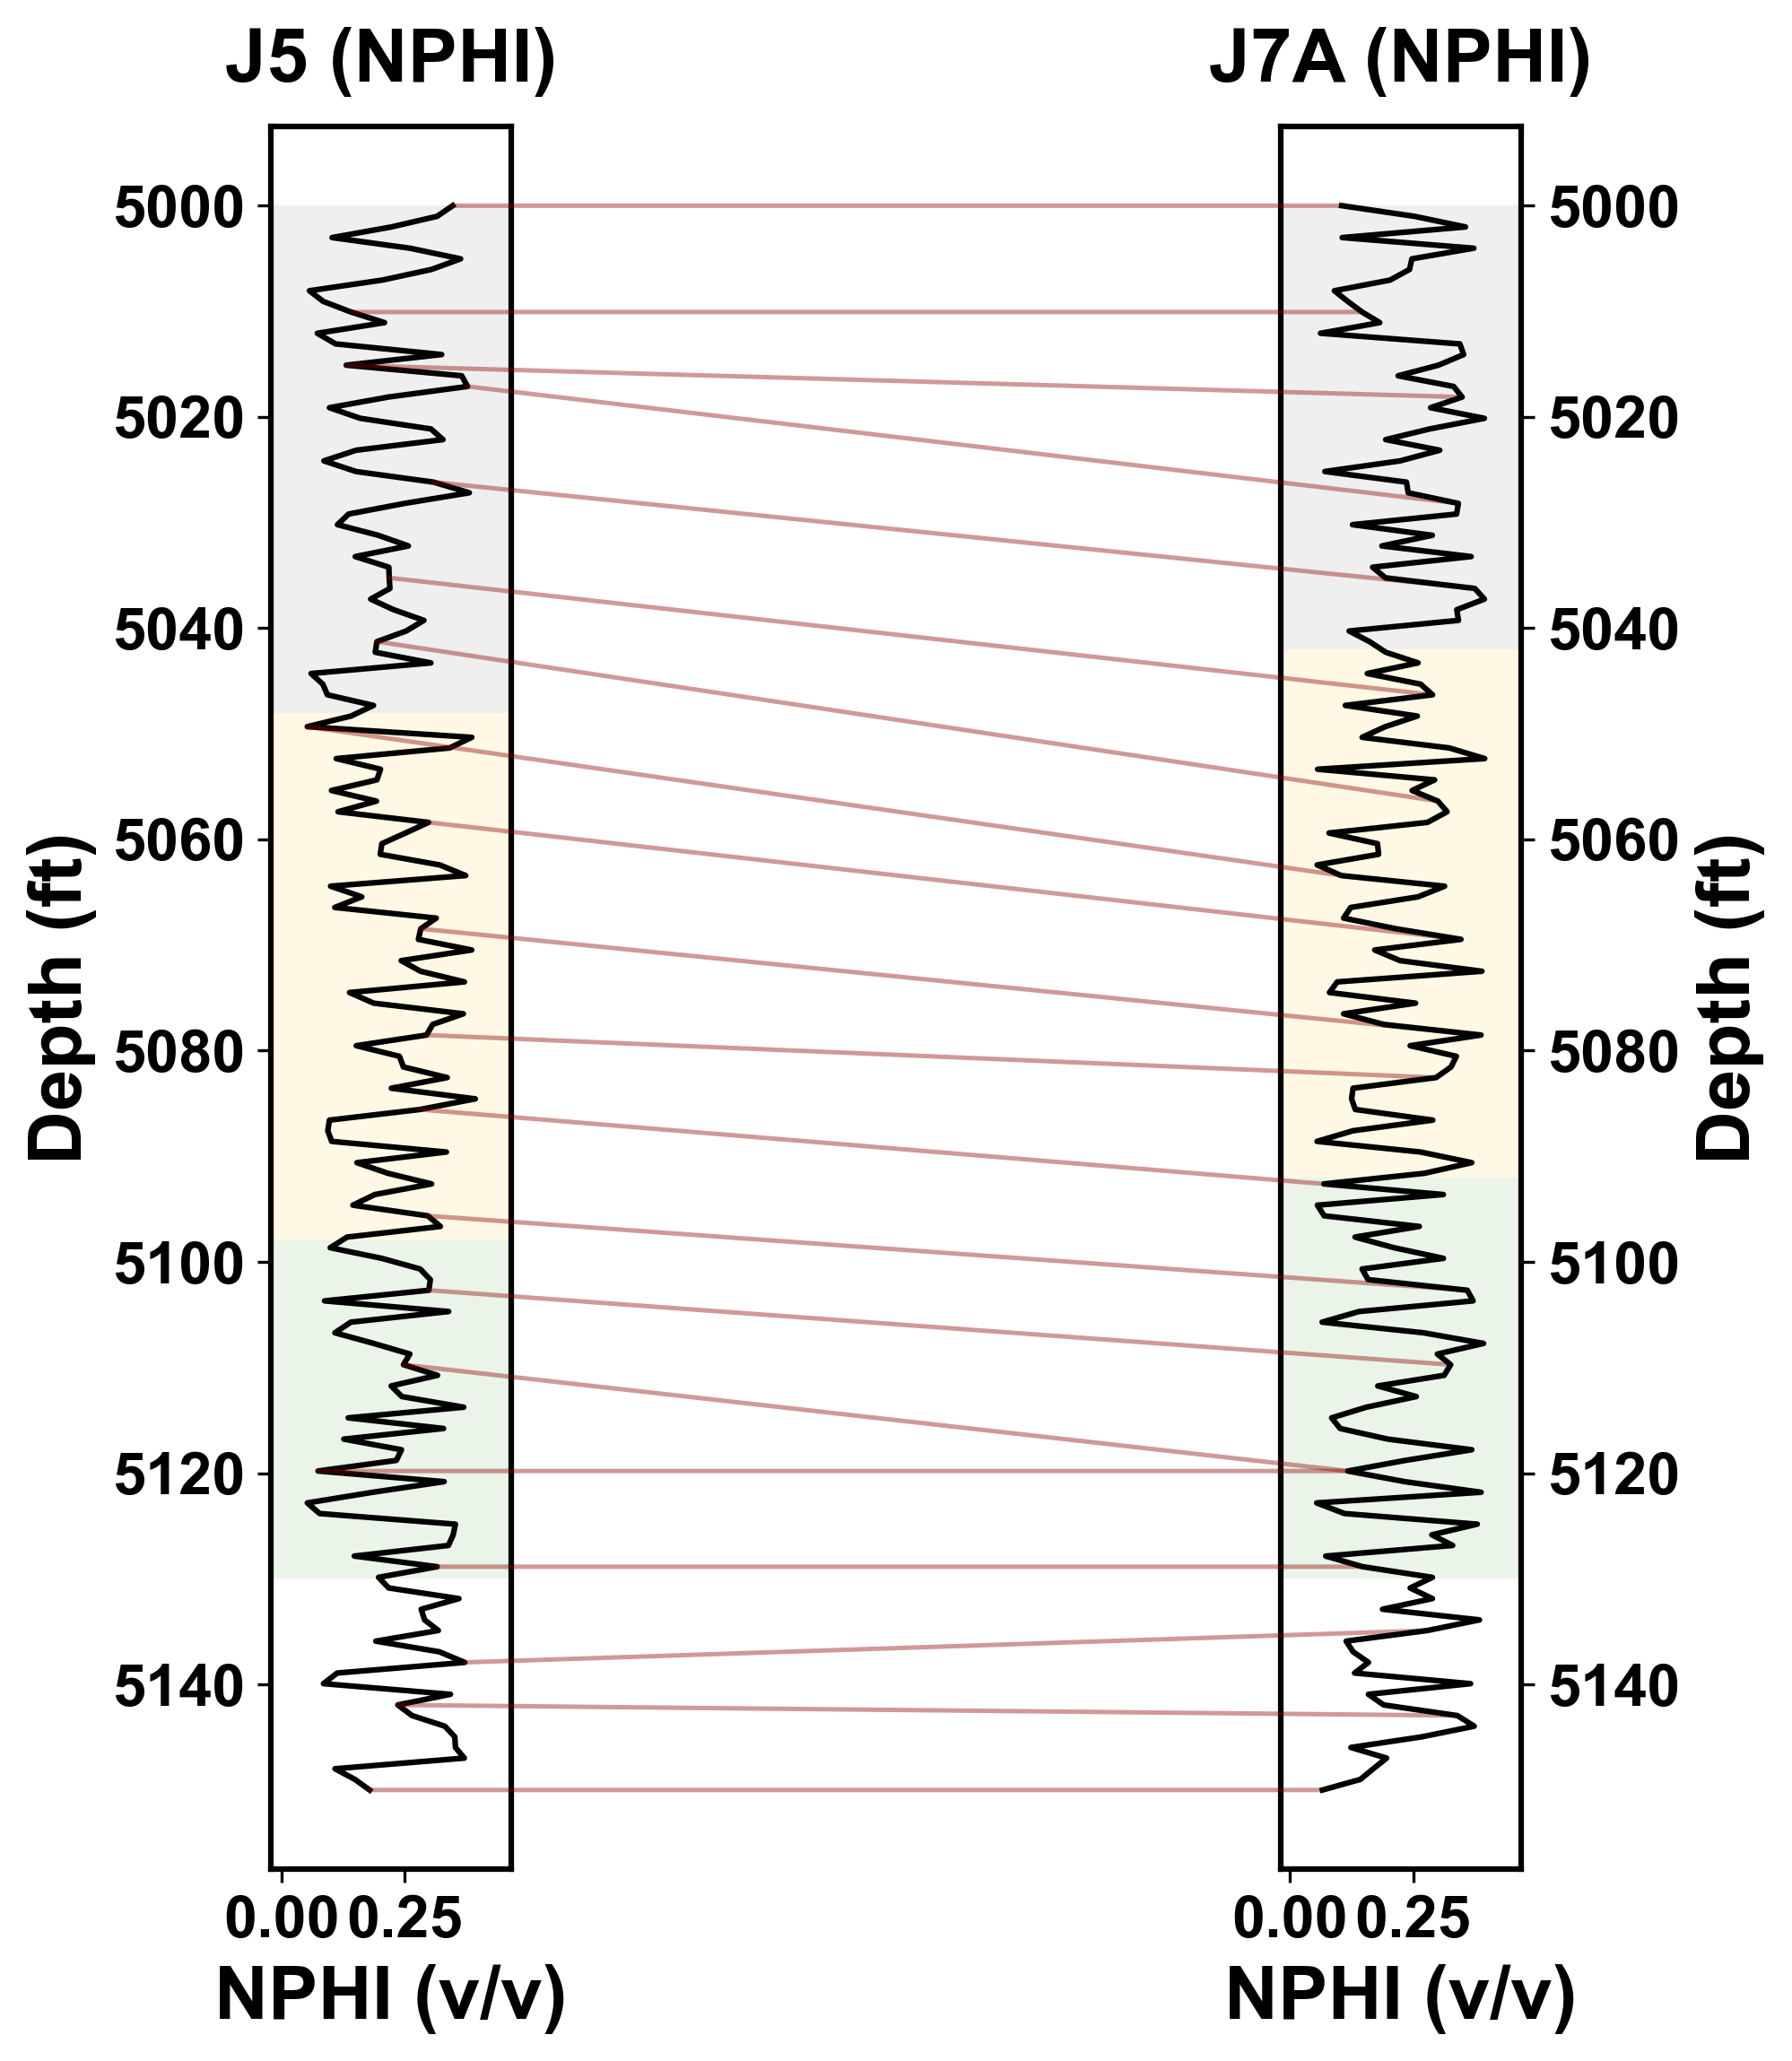

In [26]:
def plot_nphi_correlation_matched(df1, df2, zones1, zones2, label1, label2, window_p):
    # 1. Standardize and smooth NPHI logs (using column index 2)
    scaler = StandardScaler()
    nphi1_smooth = medfilt(df1.iloc[:, 2].values, kernel_size=5)
    nphi2_smooth = medfilt(df2.iloc[:, 2].values, kernel_size=5)
    
    s1 = scaler.fit_transform(nphi1_smooth.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(nphi2_smooth.reshape(-1,1)).flatten()
    
    # 2. Get DTW path (using the window parameter)
    # Using your dynamic custom window method from the notebook history
    n, m = len(s1), len(s2)
    window_size = int(np.ceil(window_p * max(n, m)))
    
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(max(1, i - window_size), min(m + 1, i + window_size + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
            
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        left = dtw_matrix[i-1, j-1]
        up = dtw_matrix[i-1, j]
        down = dtw_matrix[i, j-1]
        step = np.argmin([left, up, down])
        if step == 0: i, j = i-1, j-1
        elif step == 1: i -= 1
        else: j -= 1
    path = path[::-1]

    # 3. MATCHING FIGURE SIZE (7x8)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8))

    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        nphi = df.iloc[:, 2]
        
        # LOG LINE (Black, lw=1.5)
        ax.plot(nphi, depth, color='black', lw=1.5, zorder=5)
        
        ax.invert_yaxis()
        ax.set_title(f"{name} (NPHI)", fontweight='bold', pad=12)
        ax.set_xlabel("NPHI (v/v)")
        ax.set_ylabel("Depth (ft)")

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()

        # BOLD TICKS
        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontweight('bold')

        # STRATIGRAPHIC ZONES (Using facecolor)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # MATCHING WELL BOX WIDTH (Widen x-limits)
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Border/Spines
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')
            
        ax.grid(False)

    # 4. CORRELATION LINES (Dark Red, matches GR layout)
    line_density_step = 10  
    for k in range(0, len(path), line_density_step):
        i1, i2 = path[k]
        y1, x1 = df1.iloc[i1, 0], df1.iloc[i1, 2]
        y2, x2 = df2.iloc[i2, 0], df2.iloc[i2, 2]

        con = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color="darkred", lw=1.2, alpha=0.4, zorder=4
        )
        axes[1].add_artist(con)

    # Clean up layout
    plt.tight_layout()
    
    # Save Logic
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_NPHI_Correlation_Matched.jpg"
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.05)

    print(f"Matched NPHI Correlation Plot saved to: {save_path}")
    plt.show()

# --- EXECUTE ---
plot_nphi_correlation_matched(df_j5, df_j7a, zones_j5, zones_j7a, "J5", "J7A", 0.11)